In [ ]:
"""
This script generates synthetic 2D images of a star-shaped pattern with varying signal-to-noise ratios (SNRs) 
and corresponding ground truth images. The generated data is saved in HDF5 format for further processing 
(e.g., by a convolutional neural network). Additionally, optional TIFF files and an ImageJ macro can be 
generated for visualization and analysis.

Usage:
    Run the notebook directly to generate the synthetic data and save it in the specified formats. 
    Uncomment the optional sections to generate TIFF files and an ImageJ macro.
    - The random number generator is fixed with a seed for repeatable executions.
    - The script assumes the working directory is writable for saving the output files.
"""

import numpy as np
import h5py

# Fix random number generator for repeatable executions
RNG = np.random.default_rng(seed=20250113)

# ------------ Data generation parameters  --------------
MONTE_CARLO_SAMPLES = 10
PSFW = 2
WIDTH = 50
HEIGTH = 50
BCKG = 100 #100
STD = 13 #13
UPSCALE = 4
DEG = np.pi/180.
THETA_STEP = 45*DEG
snrs = np.logspace(0, 3, 11)

# ------------ Helper functions  --------------
def norm(img):
    _img = img - np.min(img)
    return _img/np.sum(_img)


def gauss_2d(xy, amplitude, xo, yo, sigma_x, sigma_y, theta, offset):
    """
    Computes a 2D Gaussian function.

    Parameters:
        xy (tuple of ndarray): A tuple containing two 2D arrays (x, y) representing the grid coordinates.
        amplitude (float): The amplitude (peak value) of the Gaussian function.
        xo (float): The x-coordinate of the center of the Gaussian.
        yo (float): The y-coordinate of the center of the Gaussian.
        sigma_x (float): The standard deviation of the Gaussian in the x-direction.
        sigma_y (float): The standard deviation of the Gaussian in the y-direction.
        theta (float): The rotation angle of the Gaussian in radians.
        offset (float): The constant offset added to the Gaussian function.

    Returns:
        ndarray: A 1D array representing the raveled 2D Gaussian function values.
        It need to be reshaped to form a 2D array.
    """
    x, y = xy
    xo = float(xo)
    yo = float(yo)
    a = (np.cos(theta)**2)/(2*sigma_x**2) + (np.sin(theta)**2)/(2*sigma_y**2)
    b = -(np.sin(2*theta))/(4*sigma_x**2) + (np.sin(2*theta))/(4*sigma_y**2)
    c = (np.sin(theta)**2)/(2*sigma_x**2) + (np.cos(theta)**2)/(2*sigma_y**2)
    g = offset + amplitude*np.exp(- (a*((x-xo)**2) + 2*b*(x-xo)*(y-yo)
                                     + c*((y-yo)**2)))
    return g.ravel()


def generate_image(xyi, noise_mean, noise_std, psf_width, h, w):
    """
    Generates a 2D image with Gaussian point sources and added noise.

    Args:
        xyi (list of tuples): A list of tuples where each tuple contains 
            (x, y, intensity) representing the coordinates and intensity 
            of a point source.
        noise_mean (float): The mean of the Gaussian noise to be added to the image.
        noise_std (float): The standard deviation of the Gaussian noise.
        psf_width (float): The width of the point spread function (PSF) for the Gaussian sources.
        h (int): The height of the generated image.
        w (int): The width of the generated image.

    Returns:
        numpy.ndarray: A 2D array representing the generated image, normalized 
        such that all pixel values sum to 1.
    """
    # img = np.clip(RNG.normal(noise_mean, noise_std,
    #               h*w).reshape(h, w), 0, None)
    img = RNG.normal(noise_mean, noise_std,
                   h*w).reshape(h, w)
    ys = np.arange(h)
    xs = np.arange(w)
    xy = np.meshgrid(xs, ys)
    for x, y, intensity in xyi:
        img += gauss_2d(xy, intensity, x, y, psf_width,
                        psf_width, 0, 0).reshape((h, w))
    # img = (img - np.min(img))
    # img = img/np.sum(img)
    return img


def generate_gt_image(xyi, h, w):
    """
    Generate a ground truth image by placing intensities at specified coordinates.

    Args:
        xyi (list of tuples): A list of tuples where each tuple contains three values 
                              (x, y, intensity). `x` and `y` are the coordinates, and 
                              `intensity` is the value to be added at that position.
        h (int): The height of the output image.
        w (int): The width of the output image.

    Returns:
        numpy.ndarray: A 2D array of shape (h, w) representing the generated image, 
                       normalized such that the sum of all pixel values equals 1.

    Notes:
        - The function rounds the `x` and `y` coordinates to the nearest integer 
          to determine the pixel location.
        - If the rounded coordinates fall outside the image dimensions, they are ignored.
        - The resulting image is normalized by dividing all pixel values by the total sum.
    """
    img = np.zeros((h, w))
    for x, y, intensity in xyi:
        x_nearest = int(np.round(x))
        y_nearest = int(np.round(y))
        if (x_nearest <= w-1) and (y_nearest <= h-1):
            img[y_nearest, x_nearest] += intensity
    return img/np.sum(img)


def upscale_xyi(xyi, scale=4):
    """
    Upscales the x and y coordinates of a list of [x, y, i] elements by a given scale factor.

    This function takes a list of [x, y, i] elements, where x and y are coordinates and i is an 
    additional value, and scales the x and y coordinates by the specified scale factor. A shift 
    is applied to center the scaled coordinates.

    Args:
        xyi (list of lists or tuples): A list of [x, y, i] elements to be upscaled.
        scale (int, optional): The scale factor to upscale the x and y coordinates. Defaults to 4.

    Returns:
        list: A list of upscaled [x, y, i] elements with the same structure as the input.
    """
    xyiarr = np.array(xyi)
    shift = (scale-1)/2
    xyiarr[:, 0] = xyiarr[:, 0]*scale + shift
    xyiarr[:, 1] = xyiarr[:, 1]*scale + shift
    return list(xyiarr)

In [12]:
# ------------ Main part  --------------
# if __name__ == '__main__':
snrs_mc = np.kron(snrs*(STD), np.ones(MONTE_CARLO_SAMPLES))

# Generate coordinates of the star-shaped pattern.
xys = np.array([(25, 25)]+[(r*np.cos(THETA_STEP*i)+25, r*np.sin(THETA_STEP*i)+25)
               for i in range(8) for r in [6, 12, 18]])
# Save the pattern parameters into numpy file.
np.savez('star_truth_info_2.npz', snrs=snrs_mc, xys=xys)

def add_snr_col(snr):
    """Add third column with SNR to an array of coordinates."""
    n = xys.shape[0]
    return np.hstack([xys, np.ones((n, 1))*snr])

# Recalculate coordinates for a 4-times finer grid.
xyi = np.array(upscale_xyi(add_snr_col(10), scale=UPSCALE))
# Synthetic data (images) for testing
stack_for_cnn = np.array([generate_image(add_snr_col(
    snr), BCKG, STD, PSFW, HEIGTH, WIDTH) for snr in snrs_mc])
# Corresponding reference images
stack_noiseless = np.array([generate_gt_image(upscale_xyi(add_snr_col(
    snr), scale=UPSCALE), HEIGTH*UPSCALE, WIDTH*UPSCALE) for snr in snrs_mc])

# Write data into H5 file to be later processed by CNN.
key = 'star_vs_snr'
dsets_ref = dict()
dsets_inp = dict()
dsets_ref[key] = np.copy(stack_noiseless)
dsets_inp[key] = np.copy(stack_for_cnn)

print("Inputs...")
with h5py.File('input_for_cnn_star_cnts.h5', 'w') as h5f:
    for key, images in dsets_inp.items():
        print(key)
        h5f.create_dataset(key, data=images.astype(
            np.float32), dtype=np.float32)

print("Inputs normed...")
with h5py.File('input_for_cnn_star.h5', 'w') as h5f:
    for key, images in dsets_inp.items():
        print(key)        
        _images = np.array([norm(im) for im in images])
        h5f.create_dataset(key, data=_images.astype(
            np.float32), dtype=np.float32)
        
print("References...")
with h5py.File('star_reference_cnts.h5', 'w') as h5f:
    for key, images in dsets_ref.items():
        print(key)
        h5f.create_dataset(key, data=images.astype(
            np.float32), dtype=np.float32)

# For conversion to tiff for MEF fitting in ThunderStorm,
# please refer to convert_inputs_for_mef.py

Inputs...
star_vs_snr
References...
star_vs_snr


In [13]:
snrs

array([   1.        ,    1.99526231,    3.98107171,    7.94328235,
         15.84893192,   31.6227766 ,   63.09573445,  125.89254118,
        251.18864315,  501.18723363, 1000.        ])

In [14]:
with h5py.File('input_for_cnn_star_cnts.h5', 'r') as h5f:
    for key in h5f.keys():
        imgs = np.array(h5f[key])

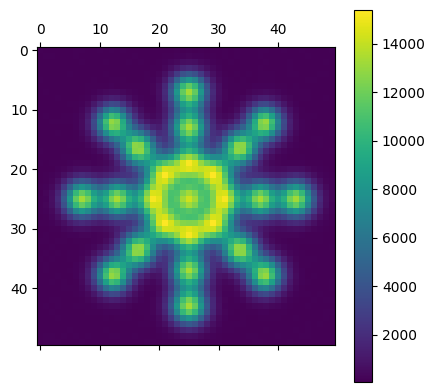

In [15]:
import matplotlib.pyplot as plt
plt.matshow(imgs[-1])
plt.colorbar()
plt.show()